# Gradient Boosting Regressor (GBR)

**Grid Search over hyperparameters**

Author: Pete King

We test the performance of an ensemble decision tree based on the concept of gradient boosting, where many weak learners are combined to provide predictions that are less likely to overfit to training data.  Compared to time series methods like ARIMA and the LSTM deep-learning model, the GBR estimator assumes no relationship between observations at different timestamps -- a disadvantage when forecasting time-series data.  However, the GBR retains an advantage over a linear model like Ridge because it can deal with non-linear relationships in the data.

In this project, we examine how well such a model can predict future volatility for an ETF over a moderate horizon, given a feature vector of market, macroeconomic, and other financial variables.  Specifically, each observation is a feature vector (**x_t**) that contains the daily return for the ETF, its near-term historic volatility, and other features at time **t** (a daily observation).  The label (**y_t**) is the mid-term future volatility, which we computed earlier using a rolling window.

Unlike other classic machine learning estimators, the GBR estimator works as a decision tree and does not require us to standardize our input features.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'

## I. Import data

We import data and separate the features from the labels.  Again we take care to preserve chronological order of observations when conducting cross-validation.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels
# Exclude returns as they show low correlation with future volatility
data_cols, _ = dp.get_X_y_cols(train_df, returns=False)
label_col = [TICKER + '_vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=21
)

## II. Define model, fit to data, and evaluate performance

Here we conduct a grid search over several important hyperparameters.

 - **learning rate** shrinks the contribution of each individual "weak learner" decision tree
 - **n_estimators** represents the number of boosting stages to perform
 - **max_features** limits the number of features allowed at each boosting stage
 - **max_depth** limits the depth of the decision tree at each stage

Decreasing the learning rate while increasing the number of estimators is like taking a larger sample and averaging results.

Max depth is perhaps the most important hyperparameter, and we keep it low to avoid overfitting to the training data.

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
estimator = GradientBoostingRegressor(loss='absolute_error', warm_start=False)
metrics = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MSE': 'neg_mean_squared_error',
    'r2': 'r2'
}
params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 5],
    'max_features': ['sqrt', None]
}
reg = GridSearchCV(
    estimator,
    params,
    scoring=metrics,
    refit='MAE',
    cv=ts_cv
)

In [5]:
reg.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...solute_error')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', None], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'RMSE': 'neg_root_mean_squared_error', 'r2': 'r2'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesS

### Visualize performance; Check evaluation metrics

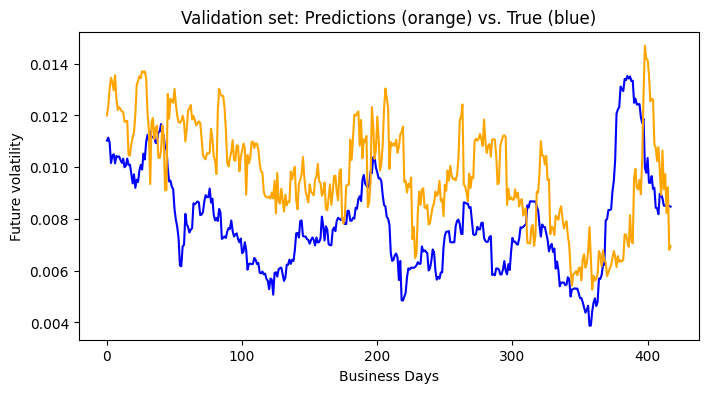

In [9]:
# Use the best estimator to make predictions on the validation set
best = reg.best_estimator_
preds = best.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [7]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.002586582183285961
R2: -1.3372273797884202


Here we see reduced MAE compared to the Ridge model using the full feature set (down from 0.0045 to 0.0026), as well as an improved (though still negative) R-squared (up from -6.1 to -1.3).  Visually, we can see that the predictions still show a pronounced lag with actual future volatility.  Our model typically does not spike until actual volatility is already returning to a lower baseline value.  Such a delayed response often results in the model going the wrong way, explaining the negative R-squared value.

## III. Inspect model

In part we chose a decision tree based model because the implementations in scikit-learn give us an easy way to understand which features are most important in its decision-making process.  Up to this point we are not sure which of the various macroeconomic data and market indicies contribute significantly to accurate predictions.  Let's take a look and see which features have been most important for our best-performing GBR.

In [8]:
feature_importances = list(
    zip(best.feature_names_in_, best.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

^VIX: 0.072
real_GDP_chg: 0.069
XLY_vol-h: 0.053
SPY_vol-h: 0.052
debt_to_GDP_chg: 0.051
^VXN: 0.045
core_PCE_chg: 0.034
XLRE_vol-h: 0.032
XLE_vol-h: 0.028
XLK_vol-h: 0.028
nominal_GDP_chg: 0.025
producer_price_index_chg: 0.024
debt_interest_chg: 0.024
female_unemployment_rate_chg: 0.023
unemployment_rate_chg: 0.022
average_duration_of_unemployment_chg: 0.022
^MOVE: 0.022
IWM_vol-h: 0.021
XLV_vol-h: 0.020
XLI_vol-h: 0.020
teenager_unemployment_rate_chg: 0.020
TIP_vol-h: 0.018
core_PCI_chg: 0.018
SHY_vol-h: 0.017
BND_vol-h: 0.016
NG=F_vol-h: 0.016
QQQ_vol-h: 0.015
HYG_vol-h: 0.015
consumer_price_index_chg: 0.014
^GSPC_vol-h: 0.014
IEF_vol-h: 0.012
BIL_vol-h: 0.011
LQD_vol-h: 0.011
GLD_vol-h: 0.010
HG=F_vol-h: 0.010
personal_consumption_expenditure_chg: 0.009
male_unemployment_rate_chg: 0.008
adult_unemployment_rate_chg: 0.008
^HSI_vol-h: 0.008
TLT_vol-h: 0.008
XLF_vol-h: 0.008
XLP_vol-h: 0.007
GC=F_vol-h: 0.007
CL=F_vol-h: 0.006
initial_jobless_claims_chg: 0.006
XLB_vol-h: 0.005
XLU_vol

As expected, two of the volatility indicies (VIX and VXN) rank highly in feature importance.  As these indicies are known to lag behind actual market volatility, it's tempting to explain the lag in our model as an over-reliance on these volatility indicies.

Interestingly, a few of the GDP-related macroeconomic features rank highly in feature importance as well -- not something I expected based on the correlation analysis we did as part of our data exploration.